In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score



<span><img src="image.png"> <img src="KMD.png"><img src="KBD2.png"></span>

In [29]:
df = pd.read_csv('ecommerce_sales_dataset.csv')
df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [30]:
df.columns

Index(['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season',
       'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price',
       'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%',
       'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method',
       'Order_Status'],
      dtype='object')

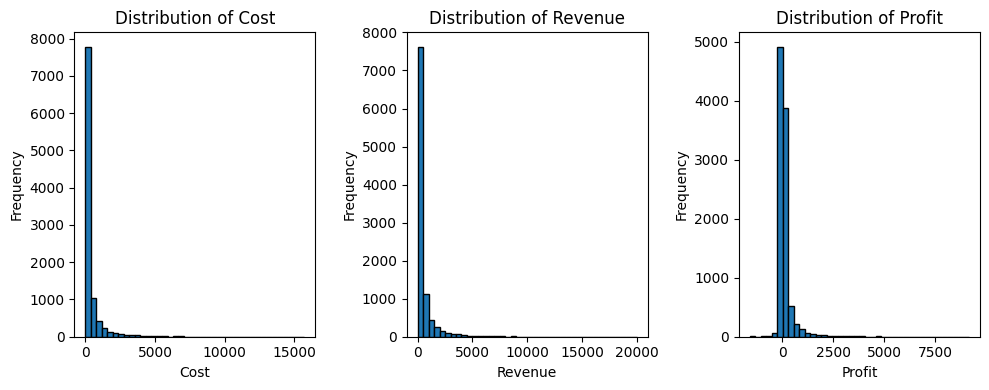

In [31]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))
ax1.hist(df['Cost'], bins=40, edgecolor='black')
ax1.set_title('Distribution of Cost')
ax1.set_xlabel('Cost')
ax1.set_ylabel('Frequency')
ax2.hist(df['Revenue'], bins=40, edgecolor='black')
ax2.set_title('Distribution of Revenue')
ax2.set_xlabel('Revenue')
ax2.set_ylabel('Frequency')
ax3.hist(df['Profit'], bins=40, edgecolor='black')
ax3.set_title('Distribution of Profit')
ax3.set_xlabel('Profit')
ax3.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

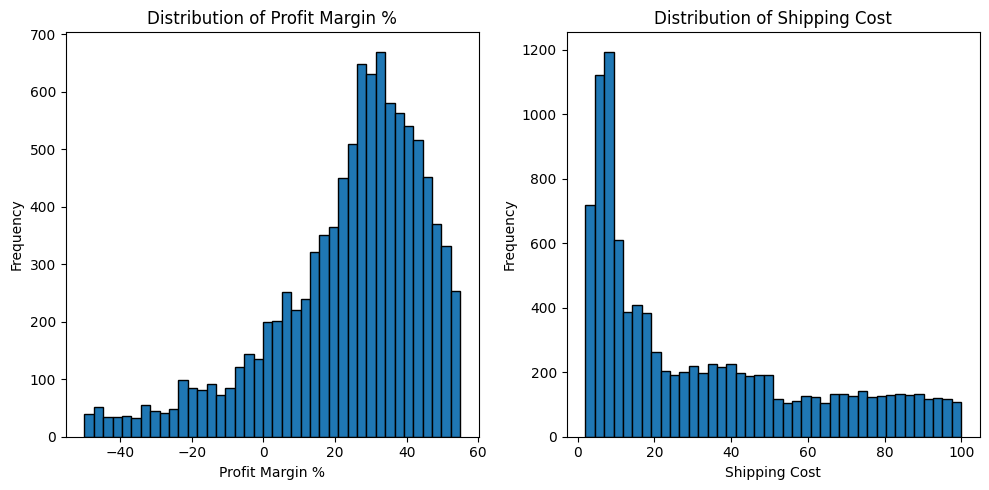

In [32]:
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.hist(df['Profit_Margin_%'], bins=40, edgecolor='black')
ax1.set_title('Distribution of Profit Margin %')
ax1.set_xlabel('Profit Margin %')
ax1.set_ylabel('Frequency')
ax2.hist(df['Shipping_Cost'], bins=40, edgecolor='black')
ax2.set_title('Distribution of Shipping Cost')
ax2.set_xlabel('Shipping Cost')
ax2.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [33]:
import enum
column_name = df.columns.tolist()
for i, col in enumerate(column_name):
    print(f"{i}: {col}")

0: Order_ID
1: Order_Date
2: Year
3: Month
4: Quarter
5: Season
6: Customer_ID
7: Customer_Gender
8: Customer_Segment
9: Region
10: Country
11: Category
12: Sub_Category
13: Product_Name
14: Unit_Price
15: Quantity
16: Discount
17: Revenue
18: Cost
19: Profit
20: Profit_Margin_%
21: Shipping_Cost
22: Shipping_Method
23: Shipping_Days
24: Payment_Method
25: Order_Status


In [41]:
## Applying function transformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def apply_log_transform(column_number1, column_number2):
    ct = ColumnTransformer(transformers=[
    ('log_cost', FunctionTransformer(func = np.log1p), [column_number1]),
    ('log_revenue', FunctionTransformer(func = np.log1p), [column_number2])
    # ('log_profit', FunctionTransformer(func = np.log1p), [column_number3])
], remainder='passthrough')
    return ct

ct1 = apply_log_transform(18, 17)
    
pipeline = Pipeline(steps=[
    ('log_transform_cost', ct1),
])

transform_ = pipeline.fit_transform(df)


df_transformed = pd.DataFrame(transform_, columns=['Log_Cost', 'Log_Revenue'] + [col for col in df.columns if col not in ['Cost', 'Revenue']])
df_transformed.head()


,Log_Cost,Log_Revenue,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,...,Unit_Price,Quantity,Discount,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,7.801845,8.200782,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,...,520.4,7,0.0,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,3.37827,3.551914,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,...,22.59,2,0.25,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,5.090124,5.490177,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,...,241.3,1,0.0,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,5.913935,6.485398,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,...,130.9,5,0.0,285.34,43.6,31.11,Express,16,Google Pay,Processing
4,4.784905,5.191956,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,...,74.51,3,0.2,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


Text(0, 0.5, 'Frequency')

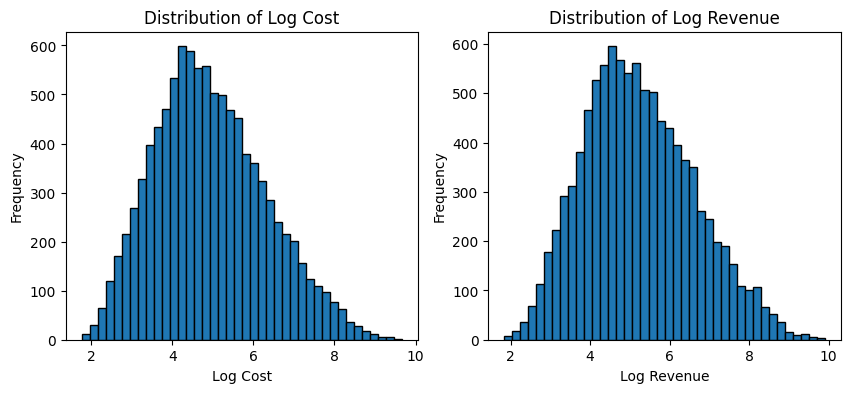

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(df_transformed['Log_Cost'], bins=40, edgecolor='black')
ax1.set_title('Distribution of Log Cost')
ax1.set_xlabel('Log Cost')
ax1.set_ylabel('Frequency')

ax2.hist(df_transformed['Log_Revenue'], bins=40, edgecolor='black')
ax2.set_title('Distribution of Log Revenue')
ax2.set_xlabel('Log Revenue')
ax2.set_ylabel('Frequency')

# ax3.hist(df_transformed['Log_Profit'], bins=40, edgecolor='black')
# ax3.set_title('Distribution of Log Profit')
# ax3.set_xlabel('Log Profit')
# ax3.set_ylabel('Frequency')
# plt.tight_layout()
# plt.show()


C:\Users\lalan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Cost Bin Edges: [array([1.76644166, 3.93216871, 4.80725352, 5.82900442, 9.66336759])]
Revenue Bin Edges: [array([1.84530024, 3.85944048, 5.87358073, 7.88772098, 9.90186123])]
   Log_Cost  Cost_Binned
0  7.801845          3.0
1   3.37827          0.0
2  5.090124          2.0
3  5.913935          3.0
4  4.784905          1.0
  Log_Revenue  Revenue_Binned
0    8.200782             3.0
1    3.551914             0.0
2    5.490177             1.0
3    6.485398             2.0
4    5.191956             1.0


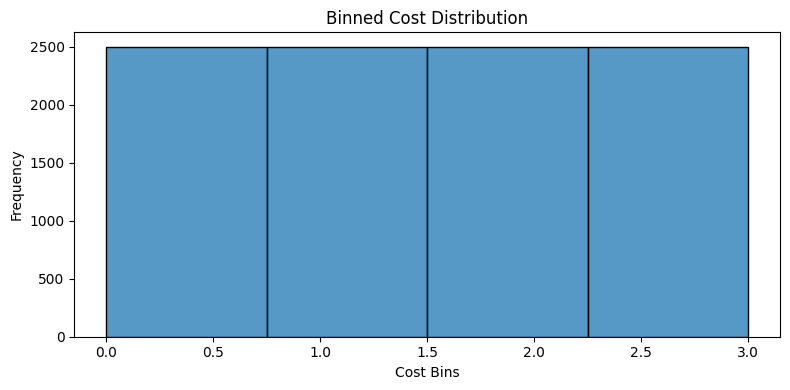

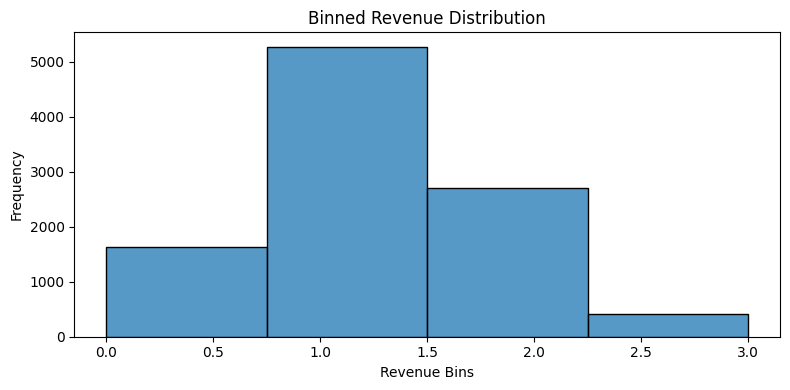

In [54]:
# Binning Cost into 4 equal-frequency bins
from sklearn.preprocessing import KBinsDiscretizer
kbins_cost = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
kbins_revenue = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
df_transformed['Cost_Binned'] = kbins_cost.fit_transform(df_transformed[['Log_Cost']])
df_transformed['Revenue_Binned'] = kbins_revenue.fit_transform(df_transformed[['Log_Revenue']])

## Get the bin edges for Cost
cost_bin_edges = kbins_cost.bin_edges_

print("Cost Bin Edges:", cost_bin_edges)
print("Revenue Bin Edges:", kbins_revenue.bin_edges_)
print(df_transformed[['Log_Cost', 'Cost_Binned']].head())
print(df_transformed[['Log_Revenue', 'Revenue_Binned']].head())


fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_transformed['Cost_Binned'], bins=4, edgecolor='black')
ax.set_title('Binned Cost Distribution')
ax.set_xlabel('Cost Bins')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_transformed['Revenue_Binned'], bins=4, edgecolor='black')
ax.set_title('Binned Revenue Distribution')
ax.set_xlabel('Revenue Bins')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()
